# Introduction: What to do when noises are not white
The output from this notebook will be used to provide answers for this lesson's practice
quiz. It shows what to do when the noises have nonzero mean.

### Implementing a standard Kalman filter with correlated sensor noise
The next notebook cells implement the standard Kalman filter, without changes, and shows results when the sensor noise is correlated.

In [2]:
load readonly/simOutXcorrV.mat % Ad Bd Cd Dd SigmaV SigmaW dT t u x z

[nx,nt] = size(x);
xhat = zeros(nx,1); SigmaX = zeros(nx,nx);
xhatstore = zeros(nx,nt); boundstore = zeros(nx,nt);

for k = 2:length(t)
  % KF Step 1a: State estimate time update      
  xhat = Ad*xhat + Bd*u(k-1); % use prior value of "u"
 
  % KF Step 1b: Error covariance time update   
  SigmaX = Ad*SigmaX*Ad' + SigmaW;
  
  % KF Step 1c: Estimate system output   
  zhat = Cd*xhat + Dd*u(k); % use present value of "u"

  % KF Step 2a: Compute Kalman gain matrix   
  SigmaZ = Cd*SigmaX*Cd' + SigmaV;
  L = SigmaX*Cd'/(Cd*SigmaX*Cd' + SigmaV);%SigmaZ;
 
  % KF Step 2b: State estimate measurement update   
  xhat = xhat + L*(z(k) - zhat);
   
  % KF Step 2c: Error covariance measurement update   
  SigmaX = (eye(nx)-L*Cd)*SigmaX;%SigmaX - L*SigmaZ*L';
 
  % [Store information for evaluation/plotting purposes]  
  xhatstore(:,k) = xhat; 
  boundstore(:,k) = 3*sqrt(diag(SigmaX));
end

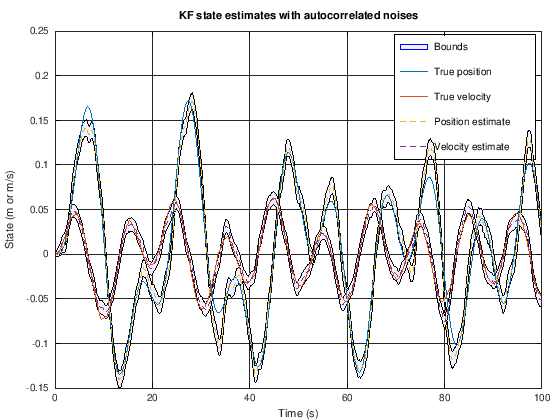

In [3]:
t2 = [t fliplr(t)]; % Prepare for plotting bounds via "fill"
x2 = [xhatstore-boundstore fliplr(xhatstore+boundstore)];
h1a = fill(t2,x2(1,:),'b',"FaceAlpha",0.05); hold on; grid on
h1b = fill(t2,x2(2,:),'b',"FaceAlpha",0.05);
h2 = plot(t,x',t,xhatstore','--'); ylim([-0.15 0.25]);
legend([h2;h1a;h1b],{'True position','True velocity','Position estimate',...
  'Velocity estimate','Bounds'}); 
title('KF state estimates with autocorrelated noises'); 
xlabel('Time (s)'); ylabel('State (m or m/s)'); 

bndErrFrac1 =  38.362
bndErrFrac2 =  19.481


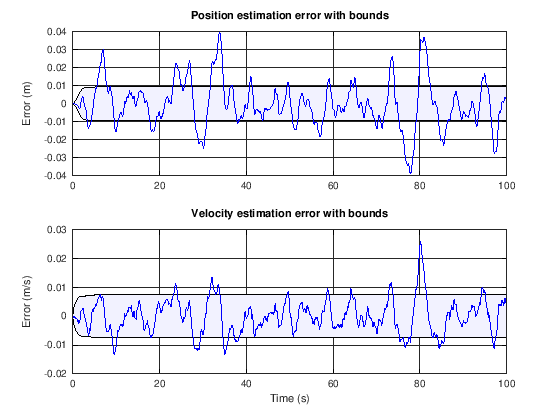

In [4]:
xerr = x - xhatstore; 
subplot(2,1,1); 
fill([t fliplr(t)],[-boundstore(1,:) fliplr(boundstore(1,:))],'b',...
  "FaceAlpha",0.05); hold on; grid on;
plot(t,xerr(1,:),'b');
title('Position estimation error with bounds'); ylabel('Error (m)'); 
bndErrFrac1 = length(find(abs(xerr(1,:))>boundstore(1,:)))/nt*100

subplot(2,1,2); 
fill([t fliplr(t)],[-boundstore(2,:) fliplr(boundstore(2,:))],'b',...
  "FaceAlpha",0.05); hold on; grid on;
plot(t,xerr(2,:),'b');
ht = title('Velocity estimation error with bounds'); 
hx = xlabel('Time (s)'); ylabel('Error (m/s)'); 
bndErrFrac2 = length(find(abs(xerr(2,:))>boundstore(2,:)))/nt*100

### Implementing a corrected Kalman filter with correlated sensor noise
The next notebook cells implement a Kalman filter that is adjusted to account for correlated sensor noise.

In [5]:
load readonly/simOutXcorrV.mat % Ad Bd Cd Dd SigmaV SigmaW dT t u x z Af Bf Cf Df

[nx,nt] = size(x);
xhat = zeros(nx+1,1); SigmaX = zeros(nx+1,nx+1);
xhatstore = zeros(nx,nt); boundstore = zeros(nx,nt);

Ad = blkdiag(Ad,Af);
Bd = [Bd; 0];
Cd = [Cd, 1];
SigmaW = blkdiag(SigmaW,SigmaV);

for k = 2:length(t)
  % KF Step 1a: State estimate time update      
  xhat = Ad*xhat + Bd*u(k-1); % use prior value of "u"
 
  % KF Step 1b: Error covariance time update   
  SigmaX = Ad*SigmaX*Ad' + SigmaW;
  
  % KF Step 1c: Estimate system output   
  zhat = Cd*xhat + Dd*u(k); % use present value of "u"

  % KF Step 2a: Compute Kalman gain matrix   
  SigmaZ = Cd*SigmaX*Cd' + SigmaV;
  L = SigmaX*Cd'/(Cd*SigmaX*Cd' + SigmaV);%SigmaZ;
 
  % KF Step 2b: State estimate measurement update   
  xhat = xhat + L*(z(k) - zhat);
   
  % KF Step 2c: Error covariance measurement update   
  SigmaX = (eye(nx+1)-L*Cd)*SigmaX;%SigmaX - L*SigmaZ*L';
 
  % [Store information for evaluation/plotting purposes]  
  xhatstore(:,k) = xhat(1:nx); 
  boundstore(:,k) = 3*sqrt(diag(SigmaX(1:nx,1:nx)));
end

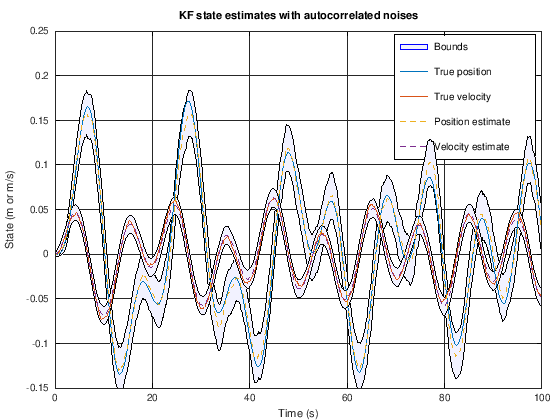

In [6]:
t2 = [t fliplr(t)]; % Prepare for plotting bounds via "fill"
x2 = [xhatstore-boundstore fliplr(xhatstore+boundstore)];
h1a = fill(t2,x2(1,:),'b',"FaceAlpha",0.05); hold on; grid on
h1b = fill(t2,x2(2,:),'b',"FaceAlpha",0.05);
h2 = plot(t,x',t,xhatstore','--'); ylim([-0.15 0.25]);
legend([h2;h1a;h1b],{'True position','True velocity','Position estimate',...
  'Velocity estimate','Bounds'}); 
title('KF state estimates with autocorrelated noises'); 
xlabel('Time (s)'); ylabel('State (m or m/s)'); 

bndErrFrac1 = 0
bndErrFrac2 = 0


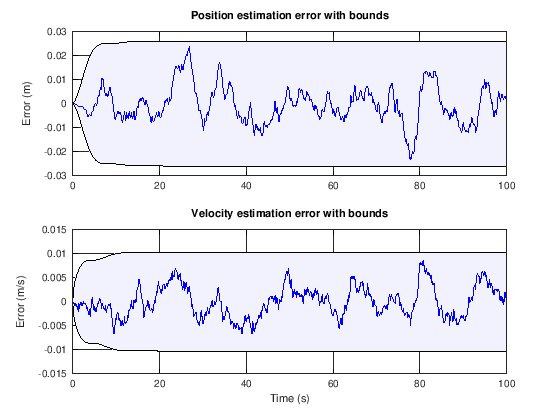

In [7]:
xerr = x - xhatstore; 
subplot(2,1,1); 
fill([t fliplr(t)],[-boundstore(1,:) fliplr(boundstore(1,:))],'b',...
  "FaceAlpha",0.05); hold on; grid on;
plot(t,xerr(1,:),'b');
title('Position estimation error with bounds'); ylabel('Error (m)'); 
bndErrFrac1 = length(find(abs(xerr(1,:))>boundstore(1,:)))/nt*100

subplot(2,1,2); 
fill([t fliplr(t)],[-boundstore(2,:) fliplr(boundstore(2,:))],'b',...
  "FaceAlpha",0.05); hold on; grid on;
plot(t,xerr(2,:),'b');
ht = title('Velocity estimation error with bounds'); 
hx = xlabel('Time (s)'); ylabel('Error (m/s)'); 
bndErrFrac2 = length(find(abs(xerr(2,:))>boundstore(2,:)))/nt*100

### Implementing a standard Kalman filter with correlated process noise
The next notebook cells implement the standard Kalman filter, without changes, and shows results when the process noise is correlated.

In [8]:
load readonly/simOutXcorrW.mat % Ad Bd Cd Dd SigmaV SigmaW dT t u x z

[nx,nt] = size(x);
xhat = zeros(nx,1); SigmaX = zeros(nx,nx);
xhatstore = zeros(nx,nt); boundstore = zeros(nx,nt);

for k = 2:length(t)
  % KF Step 1a: State estimate time update      
  xhat = Ad*xhat + Bd*u(k-1); % use prior value of "u"
 
  % KF Step 1b: Error covariance time update   
  SigmaX = Ad*SigmaX*Ad' + SigmaW;
  
  % KF Step 1c: Estimate system output   
  zhat = Cd*xhat + Dd*u(k); % use present value of "u"

  % KF Step 2a: Compute Kalman gain matrix   
  SigmaZ = Cd*SigmaX*Cd' + SigmaV;
  L = SigmaX*Cd'/(Cd*SigmaX*Cd' + SigmaV);%SigmaZ;
 
  % KF Step 2b: State estimate measurement update   
  xhat = xhat + L*(z(k) - zhat);
   
  % KF Step 2c: Error covariance measurement update   
  SigmaX = (eye(nx)-L*Cd)*SigmaX;%SigmaX - L*SigmaZ*L';
 
  % [Store information for evaluation/plotting purposes]  
  xhatstore(:,k) = xhat; 
  boundstore(:,k) = 3*sqrt(diag(SigmaX));
end

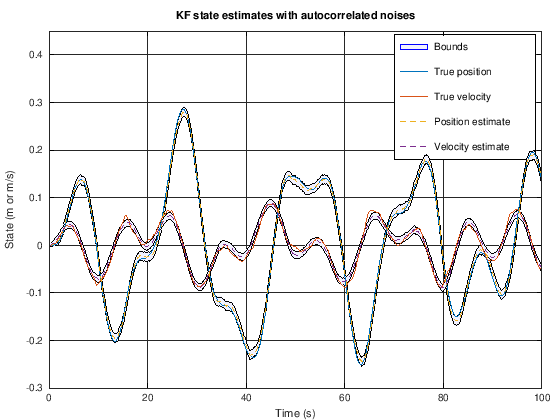

In [9]:
t2 = [t fliplr(t)]; % Prepare for plotting bounds via "fill"
x2 = [xhatstore-boundstore fliplr(xhatstore+boundstore)];
h1a = fill(t2,x2(1,:),'b',"FaceAlpha",0.05); hold on; grid on
h1b = fill(t2,x2(2,:),'b',"FaceAlpha",0.05);
h2 = plot(t,x',t,xhatstore','--'); ylim([-0.3 0.45]);
legend([h2;h1a;h1b],{'True position','True velocity','Position estimate',...
  'Velocity estimate','Bounds'}); 
title('KF state estimates with autocorrelated noises'); 
xlabel('Time (s)'); ylabel('State (m or m/s)'); 

bndErrFrac1 =  18.282
bndErrFrac2 =  40.060


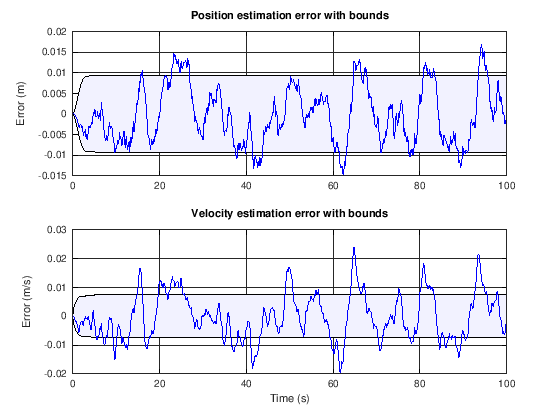

In [10]:
xerr = x - xhatstore; 
subplot(2,1,1); 
fill([t fliplr(t)],[-boundstore(1,:) fliplr(boundstore(1,:))],'b',...
  "FaceAlpha",0.05); hold on; grid on;
plot(t,xerr(1,:),'b');
title('Position estimation error with bounds'); ylabel('Error (m)'); 
bndErrFrac1 = length(find(abs(xerr(1,:))>boundstore(1,:)))/nt*100

subplot(2,1,2); 
fill([t fliplr(t)],[-boundstore(2,:) fliplr(boundstore(2,:))],'b',...
  "FaceAlpha",0.05); hold on; grid on;
plot(t,xerr(2,:),'b');
ht = title('Velocity estimation error with bounds'); 
hx = xlabel('Time (s)'); ylabel('Error (m/s)'); 
bndErrFrac2 = length(find(abs(xerr(2,:))>boundstore(2,:)))/nt*100

### Implementing a corrected Kalman filter with correlated process noise
The next notebook cells implement a Kalman filter that is adjusted to account for correlated process noise.

In [11]:
load readonly/simOutXcorrW.mat % Ad Bd Cd Dd SigmaV SigmaW dT t u x z Af Bf Cf Df

[nx,nt] = size(x);
xhat = zeros(2*nx,1); SigmaX = zeros(2*nx,2*nx);
xhatstore = zeros(nx,nt); boundstore = zeros(nx,nt);

Ad = [Ad eye(nx); zeros(nx) Af];
Bd = [Bd; zeros(nx,1)];
Cd = [Cd, zeros(1,nx)];
SigmaW = blkdiag(zeros(nx),SigmaW);

for k = 2:length(t)
  % KF Step 1a: State estimate time update      
  xhat = Ad*xhat + Bd*u(k-1); % use prior value of "u"
 
  % KF Step 1b: Error covariance time update   
  SigmaX = Ad*SigmaX*Ad' + SigmaW;
  
  % KF Step 1c: Estimate system output   
  zhat = Cd*xhat + Dd*u(k); % use present value of "u"

  % KF Step 2a: Compute Kalman gain matrix   
  SigmaZ = Cd*SigmaX*Cd' + SigmaV;
  L = SigmaX*Cd'/(Cd*SigmaX*Cd' + SigmaV);%SigmaZ;
 
  % KF Step 2b: State estimate measurement update   
  xhat = xhat + L*(z(k) - zhat);
   
  % KF Step 2c: Error covariance measurement update   
  SigmaX = (eye(2*nx)-L*Cd)*SigmaX;%SigmaX - L*SigmaZ*L';
 
  % [Store information for evaluation/plotting purposes]  
  xhatstore(:,k) = xhat(1:nx); 
  boundstore(:,k) = 3*sqrt(diag(SigmaX(1:nx,1:nx)));
end

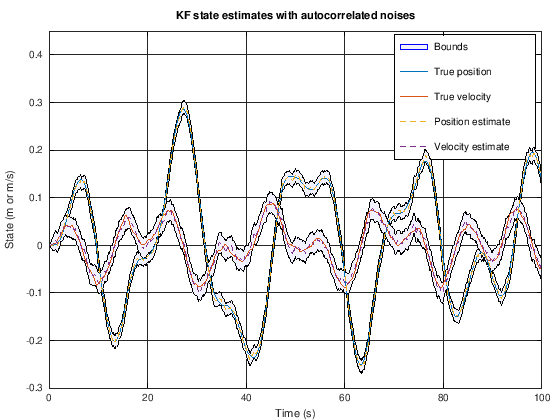

In [12]:
t2 = [t fliplr(t)]; % Prepare for plotting bounds via "fill"
x2 = [xhatstore-boundstore fliplr(xhatstore+boundstore)];
h1a = fill(t2,x2(1,:),'b',"FaceAlpha",0.05); hold on; grid on
h1b = fill(t2,x2(2,:),'b',"FaceAlpha",0.05);
h2 = plot(t,x',t,xhatstore','--'); ylim([-0.3 0.45]);
legend([h2;h1a;h1b],{'True position','True velocity','Position estimate',...
  'Velocity estimate','Bounds'}); 
title('KF state estimates with autocorrelated noises'); 
xlabel('Time (s)'); ylabel('State (m or m/s)'); 

bndErrFrac1 =  0.29970
bndErrFrac2 =  0.19980


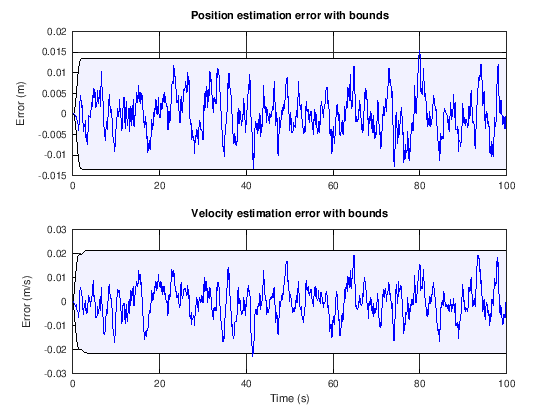

In [13]:
xerr = x - xhatstore; 
subplot(2,1,1); 
fill([t fliplr(t)],[-boundstore(1,:) fliplr(boundstore(1,:))],'b',...
  "FaceAlpha",0.05); hold on; grid on;
plot(t,xerr(1,:),'b');
title('Position estimation error with bounds'); ylabel('Error (m)'); 
bndErrFrac1 = length(find(abs(xerr(1,:))>boundstore(1,:)))/nt*100

subplot(2,1,2); 
fill([t fliplr(t)],[-boundstore(2,:) fliplr(boundstore(2,:))],'b',...
  "FaceAlpha",0.05); hold on; grid on;
plot(t,xerr(2,:),'b');
ht = title('Velocity estimation error with bounds'); 
hx = xlabel('Time (s)'); ylabel('Error (m/s)'); 
bndErrFrac2 = length(find(abs(xerr(2,:))>boundstore(2,:)))/nt*100